<a href="https://colab.research.google.com/github/Ayush28-ai/Ayush28-ai/blob/main/multimodelbraintumorclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib scikit-learn seaborn

In [ ]:
!pip install scikit-image opencv-python scikit-learn xgboost pgmpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix



In [ ]:

!pip install kaggle


In [ ]:
from google.colab import files
files.upload()  # Select the kaggle.json file


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushkumarr","key":"b8a6af184d1bd22a87f3c5ddecd47ac7"}'}

In [ ]:

!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d briscdataset/brisc2025

Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
 86% 214M/248M [00:00<00:00, 524MB/s] 
100% 248M/248M [00:00<00:00, 596MB/s]


In [ ]:
!unzip -q brisc2025.zip

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Directories
train_dir = "brisc2025/classification_task/train"
test_dir = "brisc2025/classification_task/test"


# Load MobileNetV2 without top layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64,64,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Image generator
datagen = ImageDataGenerator(rescale=1./255)
batch_size = 128  # larger batch size for speed

# Generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(64,64),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

# Efficient batch feature extraction
def extract_features(generator, model):
    features, labels = [], []
    for x_batch, y_batch in generator:
        feat_batch = model.predict(x_batch, verbose=0)
        features.append(feat_batch.reshape(feat_batch.shape[0], -1))
        labels.append(y_batch)
        if len(labels)*generator.batch_size >= generator.samples:
            break
    X = np.vstack(features)
    y = np.hstack(labels)
    return X, y

# Extract features
X_train, y_train = extract_features(train_generator, model)
X_test, y_test = extract_features(test_generator, model)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to reduce dimensionality and speed up model training
pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Train shape after PCA: {X_train_pca.shape}, Test shape after PCA: {X_test_pca.shape}")


/tmp/ipython-input-3578409514.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64,64,3))


Found 5000 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.
Train shape after PCA: (5000, 300), Test shape after PCA: (1000, 300)


Training machine learning models on BRISC 2025 dataset...

Training Logistic Regression...
Logistic Regression Accuracy: 0.8650

Training KNN...
KNN Accuracy: 0.8190

Training SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM Accuracy: 0.8630

Training Naive Bayes...
Naive Bayes Accuracy: 0.5580

Training Decision Tree...
Decision Tree Accuracy: 0.6890

Training Random Forest...
Random Forest Accuracy: 0.8420

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:37:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8860

Training AdaBoost...
AdaBoost Accuracy: 0.6510

Training MLP...
MLP Accuracy: 0.8840



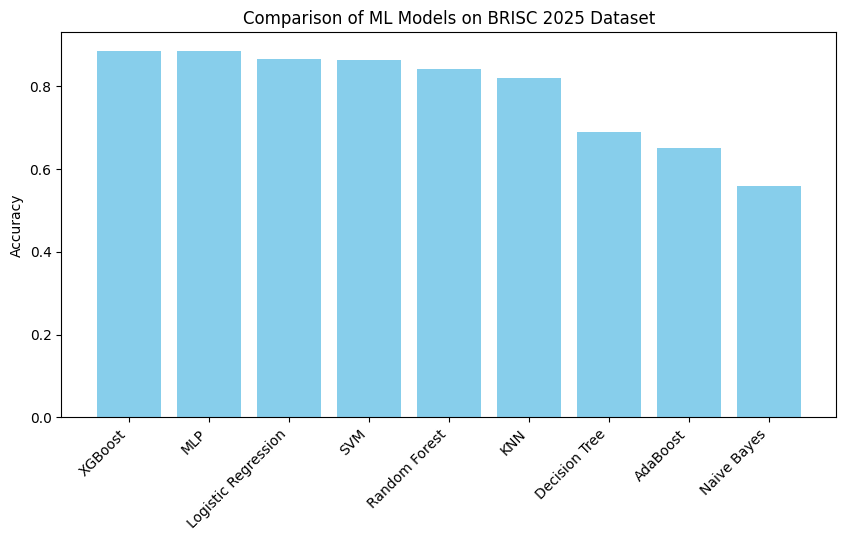

Best model: XGBoost
              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82       254
         1.0       0.81      0.89      0.85       306
         2.0       0.93      0.98      0.95       140
         3.0       0.94      0.95      0.95       300

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.88      1000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Initialize machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": LinearSVC(max_iter=3000, random_state=42),  # faster than SVC with probability
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=42)
}

# Train models and store accuracy
results = {}

print("Training machine learning models on BRISC 2025 dataset...\n")
for name, model in models.items():
    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}\n")

# Sort models by accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

# Display results
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(sorted_results.keys(), sorted_results.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models on BRISC 2025 Dataset")
plt.show()

# Print detailed classification report for the best model
best_model_name = max(results, key=results.get)
print(f"Best model: {best_model_name}")
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best))


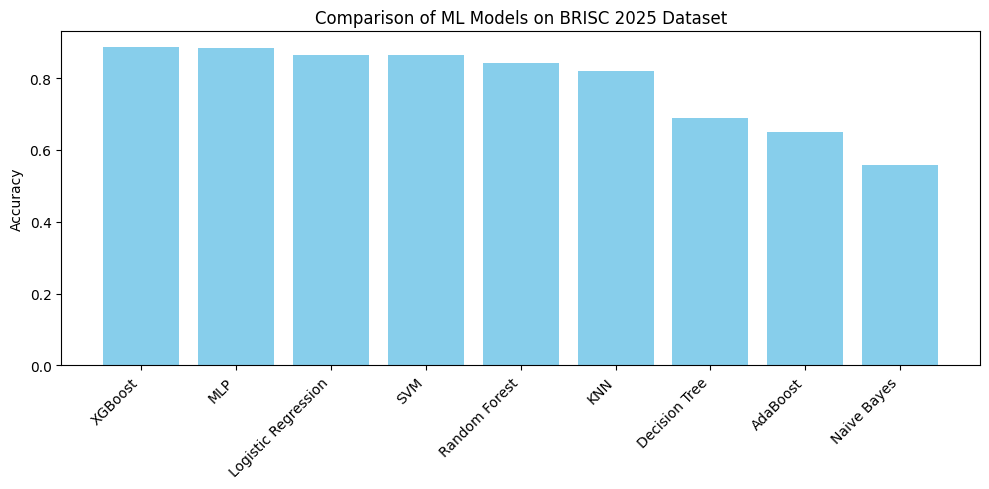

Best model: XGBoost

              precision    recall  f1-score   support

      glioma       0.90      0.76      0.82       254
  meningioma       0.81      0.89      0.85       306
    no_tumor       0.93      0.98      0.95       140
   pituitary       0.94      0.95      0.95       300

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.88      1000



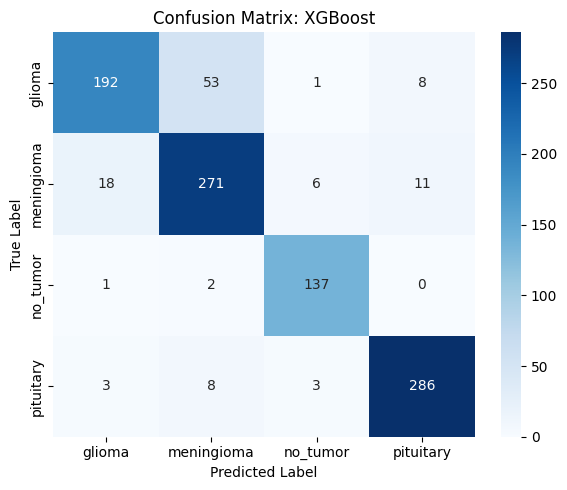

In [ ]:
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(10,5))
plt.bar(sorted_results.keys(), sorted_results.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models on BRISC 2025 Dataset")
plt.tight_layout()
plt.show()

# Detailed report for best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

# Get class names from generator
class_names = list(train_generator.class_indices.keys())
print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

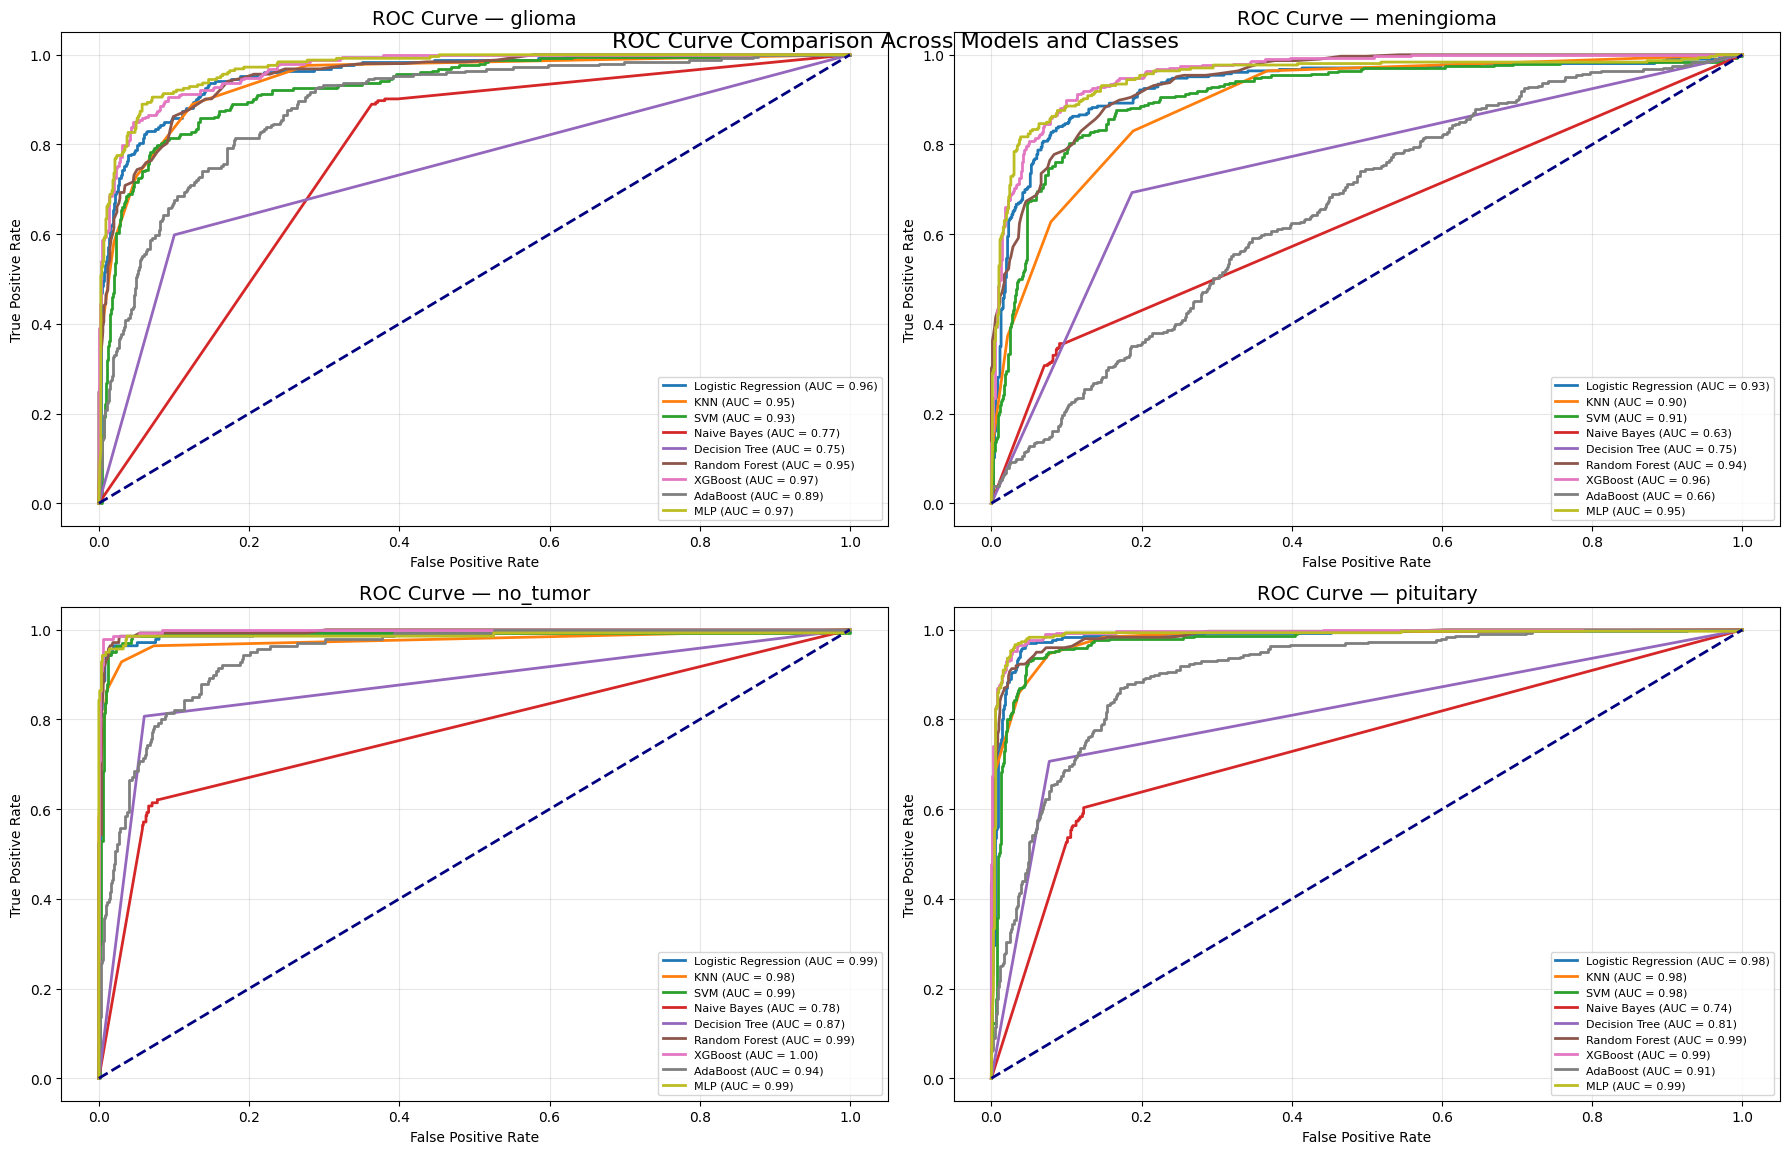

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize true labels for multi-class ROC (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]
class_names = list(train_generator.class_indices.keys())

# Compute ROC curves and AUC for each model and class
plt.figure(figsize=(18, 12))
for idx, cls in enumerate(class_names):
    plt.subplot(2, 2, idx+1)
    for name, model in models.items():
        # Get scores: use predict_proba if available, otherwise decision_function
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_scaled)[:, idx]
        else:
            y_score = model.decision_function(X_test_scaled)
            # For linear svc, decision_function returns shape (n_samples, n_classes)
            if y_score.ndim > 1:
                y_score = y_score[:, idx]
        # Compute ROC curve and AUC
        fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    # Diagonal line
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
    plt.title(f'ROC Curve — {cls}', fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(alpha=0.3)

plt.suptitle('ROC Curve Comparison Across Models and Classes', fontsize=16, y=0.94)
plt.tight_layout()
plt.show()
